In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df=pd.read_csv("/content/weight_height_dataset.csv")

In [ ]:
df.head()

,height,weight
0,151.97,97.76
1,176.97,109.45
2,168.40,119.55
3,146.92,93.73
4,158.06,98.25


In [ ]:
df.shape

(200, 2)

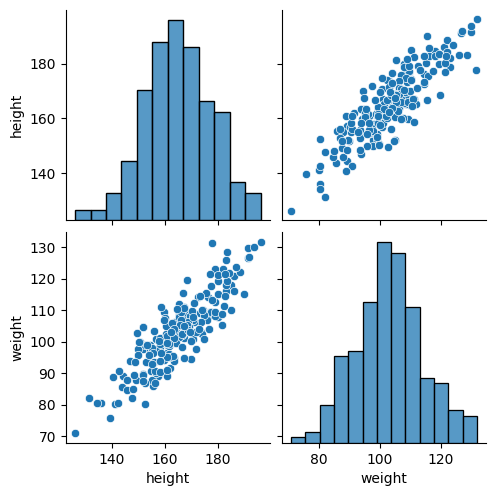

In [ ]:
import seaborn as sns
sns.pairplot(df)

Text(0, 0.5, 'height')

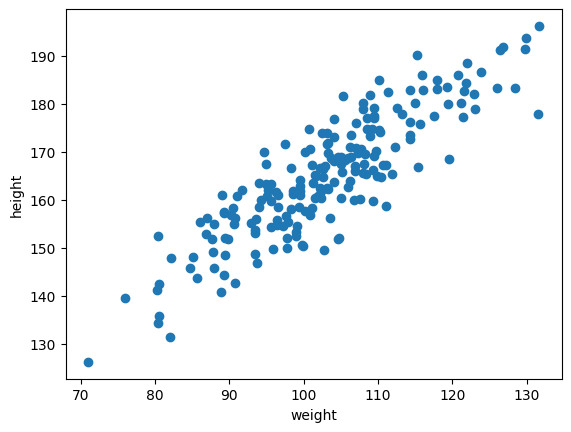

In [ ]:
plt.scatter(df['weight'],df['height'])
plt.xlabel('weight')
plt.ylabel('height')


In [ ]:
X=df[['weight']]
X.shape
X


,weight
0,97.76
1,109.45
2,119.55
3,93.73
4,98.25
...,...
195,71.01
196,99.43
197,104.13
198,99.50


In [ ]:
y=df['height']
y.shape

(200,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
X_train.shape


(150, 1)

In [ ]:
X_test.shape

(50, 1)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
print("Slope:",lr.coef_)

Slope: [11.10139259]


In [ ]:
print("Intercept:",lr.intercept_)

Intercept: 165.00086666666664


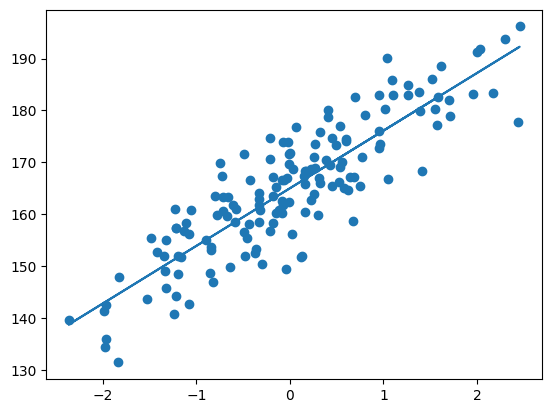

In [ ]:
plt.scatter(X_train,y_train)
plt.plot(X_train,lr.predict(X_train))

prediction_output=intercept+coef_('Weight')

In [ ]:
y_pred=lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
print("MSE:",mean_squared_error(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

MSE: 34.45363645822556
MAE: 4.555556039588946
RMSE: 5.869722008598496


In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R squared:",r2)

R squared: 0.7691161577336347


Adjusted_rsquared=1-(((1-R^2)*(N-1))/(N-P-1))

In [ ]:
adj_r2=1-(((1-(r2*r2))*(len(y_test)-1))/(len(y_test)-X_test.shape[1]-1))
print("Adjusted R squares:",adj_r2)

Adjusted R squares: 0.5830300737554273


In [ ]:
X_test.shape[1]

1

In [ ]:
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 height   R-squared (uncentered):                   0.004
Model:                            OLS   Adj. R-squared (uncentered):             -0.002
Method:                 Least Squares   F-statistic:                             0.6735
Date:                Tue, 09 Dec 2025   Prob (F-statistic):                       0.413
Time:                        07:15:43   Log-Likelihood:                         -978.84
No. Observations:                 150   AIC:                                      1960.
Df Residuals:                     149   BIC:                                      1963.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            11.1014     13.527      0.821      0.413     -15.629      37.831
==============================================================================
Omnibus:                        2.411   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.300   Jarque-Bera (JB):                2.378
Skew:                          -0.251   Prob(JB):                        0.304
Kurtosis:                       2.641   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
prediction=model.predict(X_test)
print(prediction)

[ 13.68882496   5.80161157 -11.09544779   1.91557577   3.56594159
   2.17464482   4.63100325 -21.96675287  -2.93957019  -1.51948797
   4.487076     5.43699586  -7.30536349 -12.0933434   -8.95572931
  -2.99714109  11.81777069 -17.44743716   6.59800902  -3.32337619
  17.88190556  25.38531295  -7.71795495   5.94553882   5.62889886
  -6.55694178  -4.45560391  -0.0322397   -4.46519906  -9.35872562
  -5.76054432   5.05318986   9.56291041   5.89756307   0.83132381
  -0.62713901   1.69488732  19.75295983   0.716182     4.07448454
 -17.84083832   0.83132381  -4.06220275  -5.33835772  -0.65592446
 -30.94781337  -6.60491753   3.91136699   1.34946191 -15.68192954]


In [ ]:
lr.predict(sc.transform([[50]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([113.8936429])